In [1]:
import sys
import os
import numpy as np
import pandas as pd
import datetime

import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xmitgcm as xm

sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config
#%matplotlib notebook

In [2]:
def repair_coord(ds, grid_resolution):
    ds['YC'] = np.arange(1, len(ds['YC'])+1) * grid_resolution - grid_resolution/2
    ds['XC'] = np.arange(1, len(ds['XC'])+1) * grid_resolution - grid_resolution/2
    ds['YG'] = np.arange(0, len(ds['YG'])) * grid_resolution
    ds['XG'] = np.arange(0, len(ds['XG'])) * grid_resolution

    return ds

In [3]:
dt_save = 3600
res_grid = 100

In [4]:
model = 'lucerne_summer2025'
mitgcm_config, ds = open_mitgcm_ds_from_config('..//config.json', model)

ds = repair_coord(ds, res_grid)
ds['THETA'] = ds['THETA'].where(ds['THETA'] != 0, np.nan)

In [5]:
folder_path = os.path.dirname(mitgcm_config['datapath'])
output_folder = os.path.join(folder_path, "figures", "kpp")
os.makedirs(output_folder, exist_ok=True)

## Import measure

In [6]:
year = 2025
measure_ds_path = f'../../data/measures/lucerne/walter/{year}.nc' #rmse is computed based on the 1st dataset
measure_labels = f'Walter Measure'
measure_color = 'r'

In [7]:
start_date = pd.to_datetime(ds['time'].values[0]).to_pydatetime()  #datetime(2024, 1, 1, 0, 0, 0)
end_date = pd.to_datetime(ds['time'].values[-1]).to_pydatetime() #datetime(2025, 1, 1, 0, 0, 0)

In [8]:
xr_measure = xr.open_dataset(measure_ds_path)

## Import KPP profile

In [9]:
ds_kpp = xm.open_mdsdataset(
    mitgcm_config['datapath'],
    grid_dir=mitgcm_config['gridpath'],
    ref_date=mitgcm_config['ref_date'],
    prefix='kpp_diag',
    delta_t=mitgcm_config['dt'],
    endian='>')

ds_kpp = repair_coord(ds_kpp, res_grid)

## Define secchi depth

In [10]:
secchi_depths_base = [6.8,6.5,6.3,6,5,4.5,4,4,4,4,6,6]
secchi_depths = 2 * np.array(secchi_depths_base)

## Plot

In [11]:
x_sta = 10679.05
y_sta = 9989.7777

ds_sta = ds.sel(XC=x_sta, YC=y_sta, XG=x_sta, YG=y_sta, method='nearest').compute()
ds_kpp_sta = ds_kpp.sel(XC=x_sta, YC=y_sta, XG=x_sta, YG=y_sta, method='nearest').compute()

In [12]:
def plot_profile(j):
    plt.close()
    fig, ax = plt.subplots(1,3,figsize=(10, 7))

    date_plot_profil = pd.Timestamp(ds_sta.time.values[j]).to_pydatetime()

    meas_profile = xr_measure['temp'].sel(time=date_plot_profil, method='nearest')
    ax[0].plot(meas_profile.values, meas_profile.depth.values, label=f'Idronaut measure', color='r')

    profile_mitgcm = ds_sta.THETA.sel(time=date_plot_profil, method='nearest')
    profile_mitgcm.where(profile_mitgcm != 0, np.nan).plot(y='Z', label=f'MITgcm', ax=ax[0])

    hbl = float(-ds_kpp_sta.KPPhbl.sel(time=date_plot_profil, method='nearest').values)
    ax[0].axhline(y=hbl, color='black', linestyle='--', label=f'hbl= {round(hbl,2)}m')

    secchi = secchi_depths[date_plot_profil.month-1]
    ax[0].axhline(y=-secchi, color='blue', linestyle='--', label=f'Secchi= {round(secchi,2)}m')

    ax[0].set_title(f"{date_plot_profil}")
    ax[0].grid(True, which='both', linestyle='-', linewidth=0.5)
    ax[0].set_ylabel('Depth (m)')
    ax[0].set_ylim(bottom=-100, top=1)
    ax[0].set_xlim(left=6, right=28)
    ax[0].set_xlabel('Temperature (°C)')
    ax[0].xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax[0].legend()

    ds_sta.KPPdiffT.sel(time=date_plot_profil, method='nearest').plot(y='Zl', ax=ax[1], label='KPPdiffT')
    ax[1].set_title("")
    ax[1].grid(True, which='both', linestyle='-', linewidth=0.5)
    ax[1].set_ylim(bottom=-100, top=1)
    ax[1].set_xlim(left=ds_sta.KPPdiffT.min(), right=ds_sta.KPPdiffT.max())
    ax[1].set_ylabel('')
    ax[1].xaxis.set_major_locator(ticker.MultipleLocator(0.01))
    ax[1].legend()

    speed = ds_sta.UVEL**2+ds_sta.VVEL**2
    speed.sel(time=date_plot_profil, method='nearest').plot(y='Z', ax=ax[2], label='u**2 + v**2')
    ax[2].set_title("")
    ax[2].grid(True, which='both', linestyle='-', linewidth=0.5)
    ax[2].set_ylim(bottom=-100, top=1)
    ax[2].set_xlim(left=speed.min(), right=speed.max())
    ax[2].set_xlabel('u^2 + v^2 [m^2/s^2]')
    ax[2].set_ylabel('')
    ax[2].xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax[2].legend()

    plt.savefig(os.path.join(output_folder, f"profile_{j}.png"))
    #plt.show()

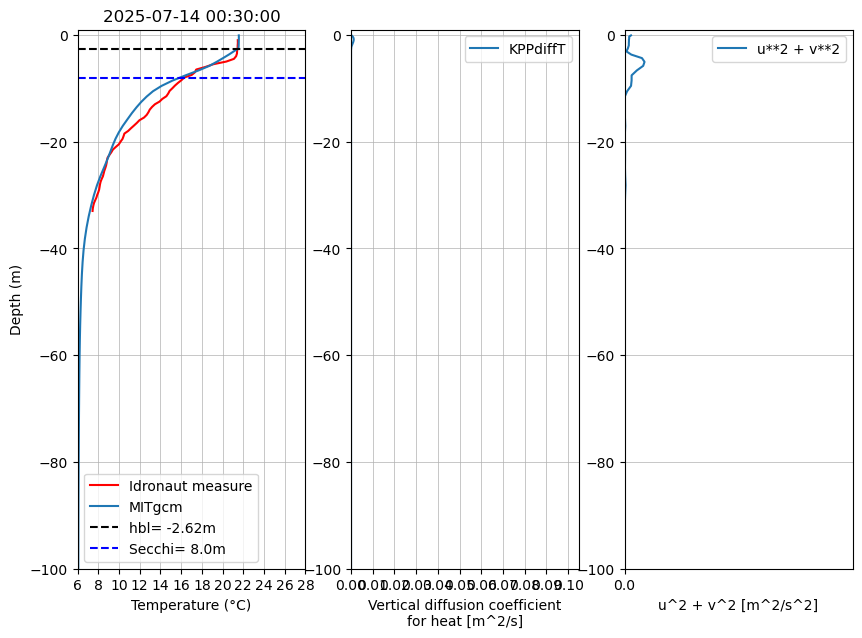

In [14]:
for i in range(293,len(ds.time.values)):
    plot_profile(i)

plot_profile(0)